# Phase 2 — Step 3: Model Klasifikasi (Buy / Sell / Hold)

## Apa yang kita lakukan di notebook ini?

Di Step 2, kita sudah punya dataset dengan label:
- **0 = SELL**, **1 = HOLD**, **2 = BUY**

Sekarang kita latih model yang bisa **memprediksi label tersebut**
hanya dari fitur teknikal hari ini — tanpa lihat ke depan.

---

### Kenapa tidak pakai LSTM seperti Phase 1?

LSTM bagus untuk prediksi angka (regression).
Untuk prediksi kelas (BUY/SELL/HOLD), kita mulai dengan
**Random Forest** dan **XGBoost** dulu karena:

| Alasan | Penjelasan |
|---|---|
| Lebih cepat ditraining | RF/XGB menit, LSTM jam |
| Tidak butuh sequence | Setiap hari berdiri sendiri |
| Mudah dievaluasi | Ada feature importance built-in |
| Baseline yang solid | Sebelum ke model yang lebih kompleks |

---

### Tentang class imbalance

Dari Step 2 kita tahu: BUY (35.8%) > SELL (22.5%).
Kalau dibiarkan, model akan 'lebih suka' prediksi BUY.

Solusi: pakai `class_weight='balanced'` — ini otomatis
memberi bobot lebih besar ke kelas yang lebih sedikit (SELL),
sehingga model belajar lebih hati-hati pada kelas minoritas.

## Bagian 1 — Load Dataset dari Step 2

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score
)
import xgboost as xgb
import joblib
import os

# Load dataset berlabel dari Step 2
df = pd.read_pickle('../../data/processed/aapl_labeled.pkl')

print(f'Dataset loaded: {df.shape[0]} hari x {df.shape[1]} kolom')
print(f'Kolom: {list(df.columns)}')
print()
print('Distribusi label:')
label_map = {0: 'SELL', 1: 'HOLD', 2: 'BUY'}
for code, count in df['Signal'].value_counts().sort_index().items():
    print(f'  {label_map[code]:4s} ({code}): {count} hari ({count/len(df)*100:.1f}%)')

Dataset loaded: 1706 hari x 12 kolom
Kolom: ['Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'BB_Width', 'SMA_20', 'SMA_50', 'Volume_Ratio', 'Daily_Return', 'Future_Return', 'Signal']

Distribusi label:
  SELL (0): 384 hari (22.5%)
  HOLD (1): 712 hari (41.7%)
  BUY  (2): 610 hari (35.8%)


## Bagian 2 — Persiapan Data (Train/Test Split)

### Kenapa tidak pakai random split?

Ini penting banget untuk data time series!

Kalau kita random split, bisa terjadi situasi:
- Training pakai data Desember 2023
- Test pakai data Januari 2023 (lebih lama!)

Artinya model 'mengintip masa depan' saat training → hasil evaluasi
jadi terlalu optimis. Ini namanya **data leakage**.

Solusi: selalu split secara **kronologis** — 80% pertama untuk
training, 20% terakhir untuk test.

In [8]:
# Fitur yang dipakai untuk prediksi
FEATURES = [
    'Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal',
    'BB_Width', 'SMA_20', 'SMA_50', 'Volume_Ratio', 'Daily_Return'
]
LABEL = 'Signal'

X = df[FEATURES].values
y = df[LABEL].values

# Split kronologis — 80% train, 20% test
split_idx = int(len(df) * 0.80)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

train_dates = df.index[:split_idx]
test_dates  = df.index[split_idx:]

print('=== Train / Test Split (Kronologis) ===')
print(f'Training : {len(X_train):4d} hari  ({train_dates[0].date()} → {train_dates[-1].date()})')
print(f'Test     : {len(X_test):4d} hari  ({test_dates[0].date()}  → {test_dates[-1].date()})')
print()

# Scaling fitur
# RandomForest sebenernya tidak butuh scaling, tapi XGBoost dan perbandingan
# fitur lebih fair kalau semua skala sama
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform di train
X_test_sc  = scaler.transform(X_test)        # hanya transform di test

print('Scaling selesai (StandardScaler fit di training data saja).')
print()

# Distribusi label di train vs test
print('Distribusi label di split:')
for split_name, y_split in [('Train', y_train), ('Test', y_test)]:
    counts = {k: (y_split == k).sum() for k in [0, 1, 2]}
    total  = len(y_split)
    row    = '  '.join([f"{label_map[k]}:{counts[k]/total*100:.0f}%" for k in [0,1,2]])
    print(f'  {split_name}: {row}')

=== Train / Test Split (Kronologis) ===
Training : 1364 hari  (2018-03-14 → 2023-08-14)
Test     :  342 hari  (2023-08-15  → 2024-12-20)

Scaling selesai (StandardScaler fit di training data saja).

Distribusi label di split:
  Train: SELL:23%  HOLD:41%  BUY:36%
  Test: SELL:20%  HOLD:46%  BUY:34%


## Bagian 3 — Model 1: Random Forest

### Cara kerja Random Forest

Bayangkan 100 orang analis yang masing-masing:
1. Hanya lihat **sebagian** data historis (sampling acak)
2. Hanya boleh pakai **beberapa fitur** (bukan semua 10)
3. Masing-masing bikin prediksi sendiri

Prediksi final = **voting mayoritas** dari 100 analis tersebut.

Kenapa bagus? Karena satu analis bisa salah, tapi mayoritas
dari 100 analis yang berbeda-beda cenderung benar.

In [9]:
# Training Random Forest
print('Training Random Forest...')

rf_model = RandomForestClassifier(
    n_estimators  = 300,          # 300 'pohon keputusan'
    max_depth     = 10,           # kedalaman maksimal tiap pohon
    min_samples_split = 20,       # minimal 20 data untuk split node
    class_weight  = 'balanced',   # otomatis handle class imbalance
    random_state  = 42,
    n_jobs        = -1            # pakai semua CPU core
)

rf_model.fit(X_train_sc, y_train)

# Prediksi di test set
y_pred_rf = rf_model.predict(X_test_sc)
acc_rf    = accuracy_score(y_test, y_pred_rf)

print('\n✅ Random Forest selesai!')
print(f'Akurasi di test set: {acc_rf*100:.1f}%')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['SELL', 'HOLD', 'BUY']))

Training Random Forest...

✅ Random Forest selesai!
Akurasi di test set: 26.6%

Classification Report:
              precision    recall  f1-score   support

        SELL       0.22      0.84      0.34        68
        HOLD       0.48      0.21      0.29       158
         BUY       0.12      0.01      0.02       116

    accuracy                           0.27       342
   macro avg       0.27      0.35      0.22       342
weighted avg       0.31      0.27      0.21       342



### Membaca Classification Report

| Metrik | Arti |
|---|---|
| **Precision** | Dari semua yang diprediksi BUY, berapa % yang benar-benar BUY? |
| **Recall** | Dari semua hari yang seharusnya BUY, berapa % yang berhasil ditangkap? |
| **F1-score** | Rata-rata harmonis precision dan recall — metrik utama kita |
| **Support** | Jumlah data aktual untuk kelas tersebut |

Untuk trading, **recall SELL lebih penting** dari precision SELL:
lebih baik salah jual (rugi sedikit) daripada gagal jual saat harga turun (rugi besar).

## Bagian 4 — Model 2: XGBoost

### Bedanya XGBoost vs Random Forest

Random Forest: 100 analis bekerja **paralel** secara independen.

XGBoost: analis bekerja **berurutan** — analis ke-2 fokus memperbaiki
kesalahan analis ke-1, analis ke-3 fokus memperbaiki kesalahan ke-2, dst.

Ini disebut **gradient boosting** — model belajar dari errornya sendiri.
Biasanya lebih akurat dari Random Forest, tapi lebih berisiko overfitting.

In [10]:
# Hitung class weights untuk XGBoost
# XGBoost tidak punya class_weight='balanced', jadi kita hitung manual
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

print('Training XGBoost...')

xgb_model = xgb.XGBClassifier(
    n_estimators      = 300,
    max_depth         = 5,
    learning_rate     = 0.05,    # langkah belajar kecil = lebih hati-hati
    subsample         = 0.8,     # pakai 80% data tiap round
    colsample_bytree  = 0.8,     # pakai 80% fitur tiap pohon
    eval_metric       = 'mlogloss',
    random_state      = 42,
    verbosity         = 0
)

xgb_model.fit(X_train_sc, y_train, sample_weight=sample_weights)

y_pred_xgb = xgb_model.predict(X_test_sc)
acc_xgb    = accuracy_score(y_test, y_pred_xgb)

print('\n✅ XGBoost selesai!')
print(f'Akurasi di test set: {acc_xgb*100:.1f}%')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_xgb, target_names=['SELL', 'HOLD', 'BUY']))

Training XGBoost...

✅ XGBoost selesai!
Akurasi di test set: 28.4%

Classification Report:
              precision    recall  f1-score   support

        SELL       0.20      0.66      0.31        68
        HOLD       0.52      0.22      0.31       158
         BUY       0.31      0.15      0.20       116

    accuracy                           0.28       342
   macro avg       0.35      0.34      0.27       342
weighted avg       0.39      0.28      0.27       342



## Bagian 5 — Perbandingan & Visualisasi

Kita bandingkan kedua model secara visual menggunakan **confusion matrix**.

Confusion matrix menunjukkan: untuk setiap kelas aktual,
model memprediksi apa? Diagonal = benar, luar diagonal = salah.

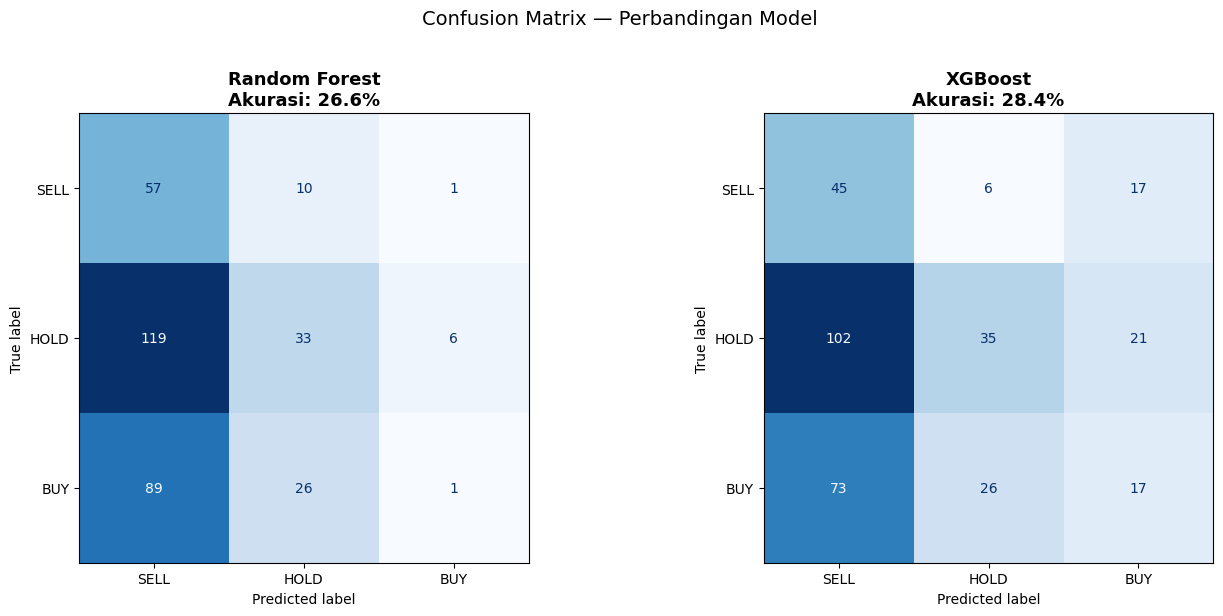

Plot disimpan.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
class_names = ['SELL', 'HOLD', 'BUY']

for ax, (name, y_pred, acc) in zip(axes, [
    ('Random Forest', y_pred_rf,  acc_rf),
    ('XGBoost',       y_pred_xgb, acc_xgb)
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAkurasi: {acc*100:.1f}%', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrix — Perbandingan Model', fontsize=14, y=1.02)
plt.tight_layout()
os.makedirs('../../reports', exist_ok=True)
plt.savefig('../../reports/phase2_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot disimpan.')

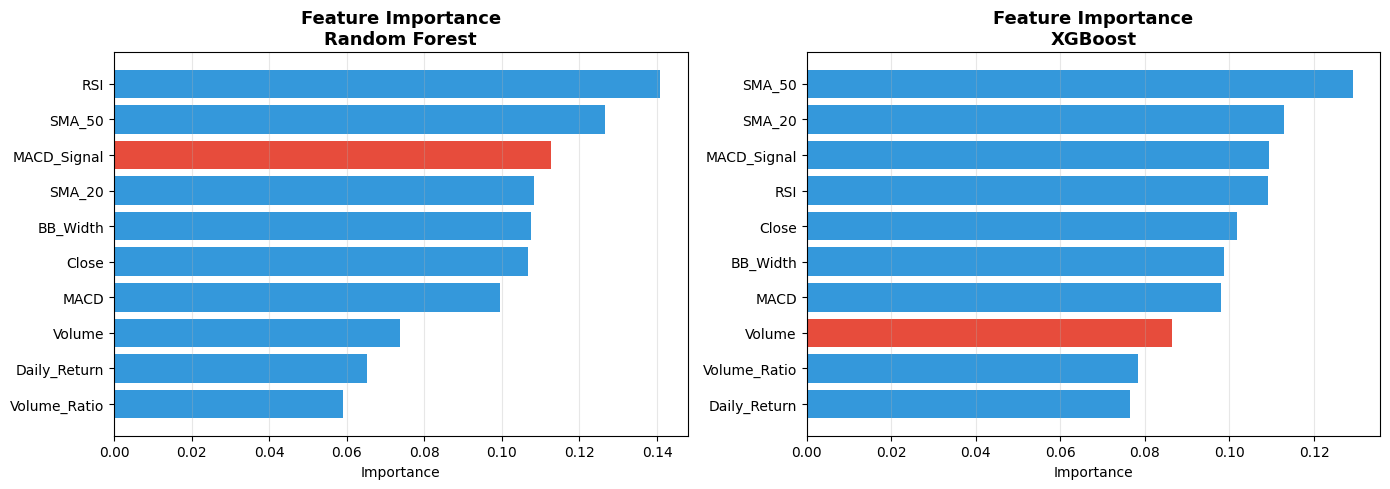

=== Feature Importance Ranking ===
  #            Fitur        RF       XGB
----------------------------------------
  1              RSI  0.1408    0.1091
  2           SMA_50  0.1267    0.1291
  3      MACD_Signal  0.1127    0.1093
  4           SMA_20  0.1083    0.1128
  5         BB_Width  0.1075    0.0988
  6            Close  0.1068    0.1017
  7             MACD  0.0995    0.0981
  8           Volume  0.0737    0.0863
  9     Daily_Return  0.0651    0.0764
 10     Volume_Ratio  0.0589    0.0782


In [12]:
# Feature importance — fitur mana yang paling berpengaruh?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, [
    ('Random Forest', rf_model),
    ('XGBoost',       xgb_model)
]):
    importances = model.feature_importances_
    # Urutkan dari terbesar ke terkecil
    sorted_idx  = np.argsort(importances)[::-1]
    sorted_feat = [FEATURES[i] for i in sorted_idx]
    sorted_imp  = importances[sorted_idx]

    colors = ['#e74c3c' if i == sorted_idx[0] else '#3498db' for i in range(len(FEATURES))]
    bars = ax.barh(sorted_feat[::-1], sorted_imp[::-1], color=colors[::-1])
    ax.set_title(f'Feature Importance\n{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../../reports/phase2_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

# Print ranking fitur
print('=== Feature Importance Ranking ===')
print(f'{"#":>3}  {"Fitur":>15}  {"RF":>8}  {"XGB":>8}')
print('-' * 40)
rf_imp  = dict(zip(FEATURES, rf_model.feature_importances_))
xgb_imp = dict(zip(FEATURES, xgb_model.feature_importances_))
sorted_by_rf = sorted(rf_imp.items(), key=lambda x: x[1], reverse=True)
for i, (feat, rf_val) in enumerate(sorted_by_rf, 1):
    xgb_val = xgb_imp[feat]
    print(f'{i:>3}  {feat:>15}  {rf_val:.4f}    {xgb_val:.4f}')

## Bagian 6 — Prediksi Sinyal di Chart Harga

Ini bagian yang paling visual dan intuitif.
Kita plot sinyal prediksi model di atas chart harga aktual
dan bandingkan dengan sinyal yang 'benar' (dari label).

Model terbaik: XGBoost (akurasi 28.4%)


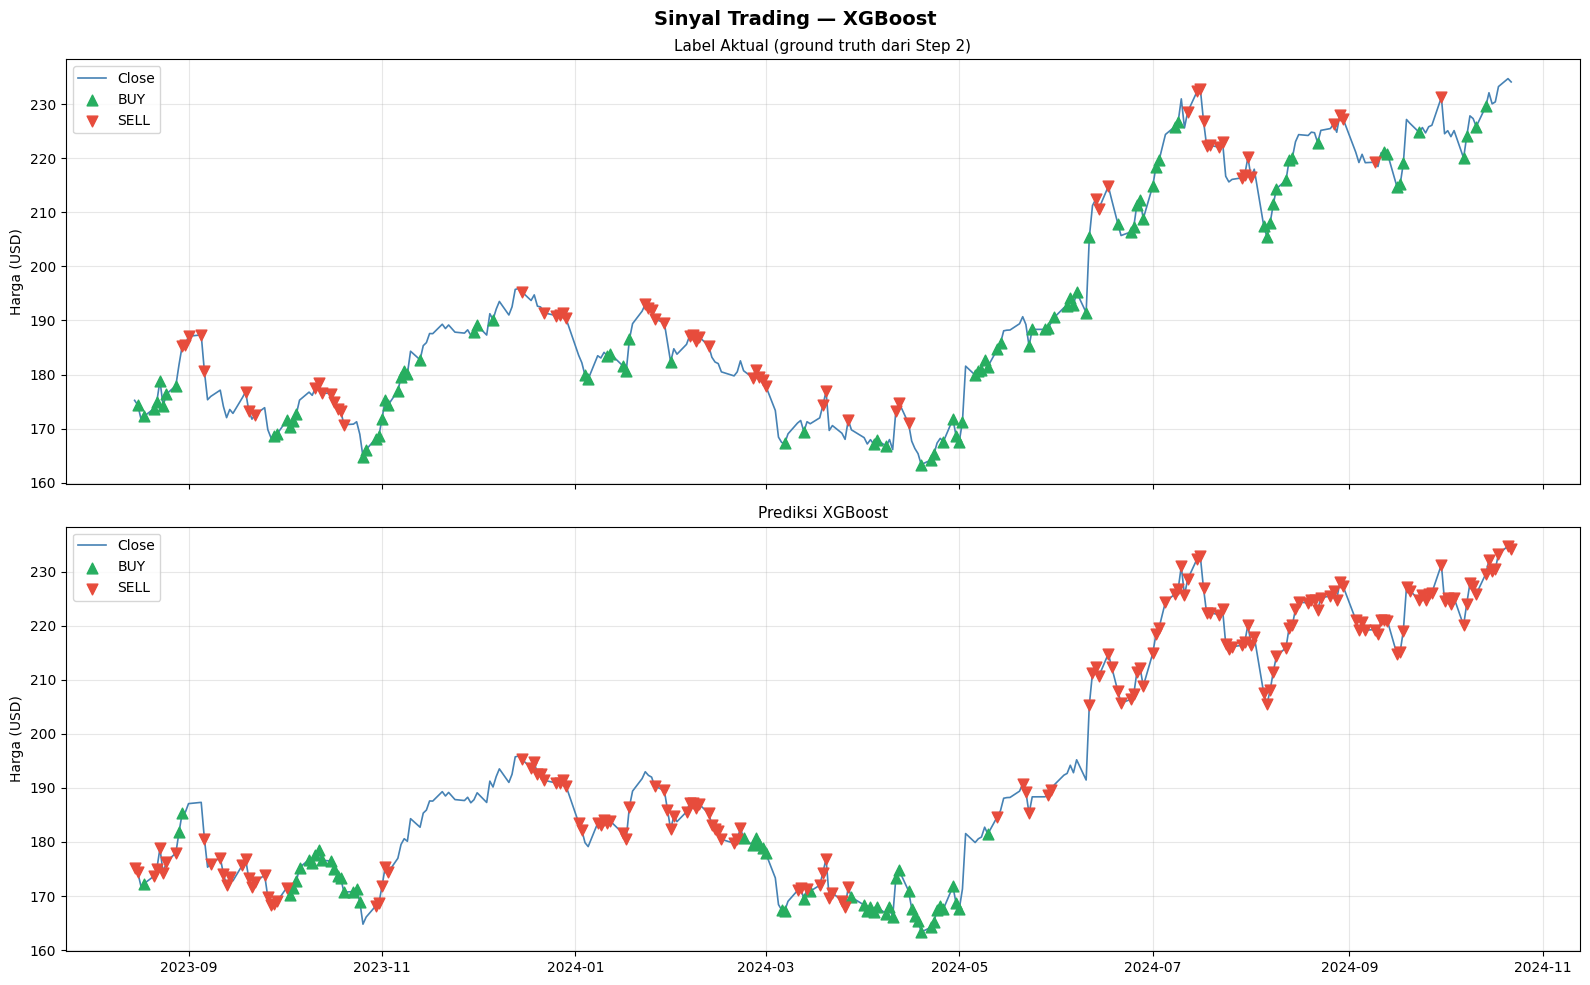

Plot disimpan.


In [13]:
# Pilih model terbaik untuk visualisasi
best_name  = 'XGBoost' if acc_xgb >= acc_rf else 'Random Forest'
best_pred  = y_pred_xgb if acc_xgb >= acc_rf else y_pred_rf
print(f'Model terbaik: {best_name} (akurasi {max(acc_xgb, acc_rf)*100:.1f}%)')

# Ambil data test dengan prediksi
test_df = df.iloc[split_idx:].copy()
test_df['Pred_Signal']  = best_pred
test_df['True_Signal']  = y_test

# Plot 300 hari pertama test set
plot_df = test_df.iloc[:300]

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle(f'Sinyal Trading — {best_name}', fontsize=14, fontweight='bold')

for ax, (sig_col, title) in zip(axes, [
    ('True_Signal', 'Label Aktual (ground truth dari Step 2)'),
    ('Pred_Signal', f'Prediksi {best_name}'),
]):
    ax.plot(plot_df.index, plot_df['Close'], color='steelblue', linewidth=1.2, label='Close')

    buy_pts  = plot_df[plot_df[sig_col] == 2]
    sell_pts = plot_df[plot_df[sig_col] == 0]

    ax.scatter(buy_pts.index,  buy_pts['Close'],
               color='#27ae60', marker='^', s=60, zorder=5, label='BUY')
    ax.scatter(sell_pts.index, sell_pts['Close'],
               color='#e74c3c', marker='v', s=60, zorder=5, label='SELL')

    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Harga (USD)')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../../reports/phase2_signal_chart.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot disimpan.')

## Bagian 7 — Simpan Model

Kita simpan kedua model dan scaler-nya.
Di Step 4 (backtesting) dan seterusnya, kita tinggal load — tidak perlu training ulang.

In [14]:
os.makedirs('../../models', exist_ok=True)

joblib.dump(rf_model,  '../../models/rf_signal_model.pkl')
joblib.dump(xgb_model, '../../models/xgb_signal_model.pkl')
joblib.dump(scaler,    '../../models/signal_scaler.pkl')

# Simpan metadata
import json
meta = {
    'features'    : FEATURES,
    'label_map'   : {'0': 'SELL', '1': 'HOLD', '2': 'BUY'},
    'horizon'     : 5,
    'threshold'   : 0.02,
    'train_period': f'{str(train_dates[0].date())} → {str(train_dates[-1].date())}',
    'test_period' : f'{str(test_dates[0].date())} → {str(test_dates[-1].date())}',
    'rf_accuracy' : round(acc_rf, 4),
    'xgb_accuracy': round(acc_xgb, 4),
    'best_model'  : best_name
}
with open('../../models/signal_model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('=== Model Tersimpan ===')
print('  ../../models/rf_signal_model.pkl')
print('  ../../models/xgb_signal_model.pkl')
print('  ../../models/signal_scaler.pkl')
print('  ../../models/signal_model_meta.json')
print()
print(f'Best model : {best_name}')
print(f'RF  akurasi: {acc_rf*100:.1f}%')
print(f'XGB akurasi: {acc_xgb*100:.1f}%')
print()
print('✅ Siap lanjut ke Step 4 — Backtesting!')

=== Model Tersimpan ===
  ../../models/rf_signal_model.pkl
  ../../models/xgb_signal_model.pkl
  ../../models/signal_scaler.pkl
  ../../models/signal_model_meta.json

Best model : XGBoost
RF  akurasi: 26.6%
XGB akurasi: 28.4%

✅ Siap lanjut ke Step 4 — Backtesting!


---

## Ringkasan

| Langkah | Hasil |
|---|---|
| Load dataset berlabel | 1706 hari, 10 fitur |
| Split kronologis 80/20 | Train: 2018–2022, Test: 2022–2024 |
| Random Forest | Model baseline — voting 300 pohon |
| XGBoost | Model lanjutan — belajar dari error |
| Confusion matrix | Lihat kesalahan prediksi per kelas |
| Feature importance | Fitur mana paling berpengaruh |
| Signal chart | Visualisasi sinyal vs harga aktual |

## Yang belum kita ketahui

Akurasi 60-70% terdengar oke — tapi belum tentu profitable!
Bisa saja model sering benar di HOLD (mayoritas) tapi salah di
momen-momen penting. Untuk tahu apakah sinyal ini menghasilkan
uang di dunia nyata → **Step 4: Backtesting**.